In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

# Add translation rate after loading the df
# Translation rate = difference in Protein Concentration_nM divided by difference in time (s), grouped by protein and DNA nM
df['translation rate [nM/s]'] = (
    df.sort_values(['protein', 'DNA nM', 'time (s)'])
      .groupby(['protein', 'DNA nM'])['Protein Concentration_nM']
      .transform(lambda x: x.diff() / df.loc[x.index, 'time (s)'].diff())
)

# Keep essential columns for behavioral analysis (removed Translation Rate aa_s as it was faulty)
columns_to_keep = ['time (s)',  'Protein Concentration_nM', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean','work [J]_mean', 'protein', 'DNA nM', 'translation rate [nM/s]']
df = df[columns_to_keep]

# Remove rows with missing protein names
df = df.dropna(subset=['protein'])

# Remove proteins that have only NaNs in velocity magnitude column
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")

# Check which proteins have only NaN velocity measurements
velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()

print(f"\nProteins with only NaN velocity measurements: {proteins_with_nan_velocity}")

# Remove these proteins
df = df[~df['protein'].isin(proteins_with_nan_velocity)]

df


Before filtering:
Total rows: 243921
Unique proteins: 17

Proteins with only NaN velocity measurements: ['B', 'BleSto', 'E', 'F']


,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,work [J]_mean,protein,DNA nM,translation rate [nM/s]
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,NaN
1,600.0,1.909813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,0.003183
2,1200.0,3.075428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,0.001943
3,1800.0,4.749361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,0.002790
4,2400.0,6.528183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,0.002965
...,...,...,...,...,...,...,...,...,...,...,...,...
243916,131220.0,122.844224,7.554028e-08,6.000483e-07,6.008068e-10,1.705629e-07,-1.453127e-07,0.000112,5.727192e-18,Kif5,160.00,-0.000985
243917,131265.0,122.777871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,-0.001475
243918,131310.0,122.759158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,-0.000416
243919,131355.0,122.815775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,0.001258


In [3]:
df.columns

Index(['time (s)', 'Protein Concentration_nM', 'vorticity [1/s]_mean',
       'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean',
       'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean',
       'work [J]_mean', 'protein', 'DNA nM', 'translation rate [nM/s]'],
      dtype='object')

In [4]:
# Find top 3 DNA concentrations with highest speeds for each protein
print(f"\nFinding top 3 DNA concentrations with highest speeds for each protein...")

# First, let's see what proteins and concentrations we have
print(f"Available proteins: {sorted(df['protein'].unique())}")
print(f"Available DNA concentrations: {sorted(df['DNA nM'].unique())}")

# Calculate mean velocity for each protein-DNA combination
velocity_summary = df.groupby(['protein', 'DNA nM'])['velocity magnitude [m/s]_mean'].mean().reset_index()
velocity_summary = velocity_summary.sort_values(['protein', 'velocity magnitude [m/s]_mean'], ascending=[True, False])

# Get top 3 concentrations for each protein
top_concentrations = {}
for protein in df['protein'].unique():
    protein_data = velocity_summary[velocity_summary['protein'] == protein]
    top_3 = protein_data.head(3)['DNA nM'].tolist()
    top_concentrations[protein] = top_3
    print(f"{protein}: {top_3} nM (speeds: {protein_data.head(3)['velocity magnitude [m/s]_mean'].values})")

# Create filter mask for top 3 concentrations per protein
filter_mask = df.apply(lambda row: row['DNA nM'] in top_concentrations.get(row['protein'], []), axis=1)
df_filtered = df[filter_mask].copy()

print(f"\nBefore filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique motor conditions: {df['protein'].nunique()}")

print(f"\nAfter filtering for top 3 concentrations per protein:")
print(f"Total rows: {len(df_filtered)}")
print(f"Unique motor conditions: {df_filtered['protein'].nunique()}")

# Now create the protein labels with DNA concentrations
df_filtered['protein'] = df_filtered['protein'].astype(str) + '-' + df_filtered['DNA nM'].astype(str) + 'nM'

print(f"\nFinal motor conditions: {sorted(df_filtered['protein'].unique())}")
print(f"DNA concentrations used: {sorted(df_filtered['DNA nM'].unique())}")

# Use the filtered dataframe
df = df_filtered

print(f"\nFinal data shape: {df.shape}")
print(f"Time range: {df['time (s)'].min():.1f} to {df['time (s)'].max():.1f} seconds")
print(f"Number of unique motor conditions: {df['protein'].nunique()}")

# Apply the same interpolation method to PIV features in the dataframe
# This follows the same approach as the velocity matrix interpolation

# PIV features to interpolate
piv_features = ['Protein Concentration_nM', 'velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 
                'strain [1/s]_mean', 'shear [1/s]_mean', 'work [J]_mean', 'translation rate [nM/s]']

print("\nApplying interpolation to PIV features in the dataframe...")
print(f"Features to interpolate: {piv_features}")

# Apply interpolation to each PIV feature for each motor condition
for feature in piv_features:
    print(f"\nInterpolating {feature}...")
    
    # Group by protein to interpolate within each motor condition
    for protein in df['protein'].unique():
        # Get the data for this protein and feature
        mask = df['protein'] == protein
        protein_data = df.loc[mask, feature].copy()
        
        if protein_data.isna().all():
            # Skip if all values are NaN
            continue
            
        # Find first and last valid indices
        first_valid = protein_data.first_valid_index()
        last_valid = protein_data.last_valid_index()
        
        if first_valid is not None and last_valid is not None:
            # Interpolate only between first and last valid points
            s_interp = protein_data.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
            
            # Reconstruct the full series: keep NaN before/after, interpolated in the middle
            s_new = pd.Series(np.nan, index=protein_data.index)
            s_new.loc[first_valid:last_valid] = s_interp
            
            # Update the dataframe
            df.loc[mask, feature] = s_new

print(f"\nInterpolation complete!")

# Show statistics before and after interpolation
print(f"\nMissing values after interpolation:")
for feature in piv_features:
    nan_count = df[feature].isna().sum()
    total_count = len(df)
    print(f"  {feature}: {nan_count}/{total_count} ({nan_count/total_count*100:.1f}%)")



Finding top 3 DNA concentrations with highest speeds for each protein...
Available proteins: ['A', 'AcSu2', 'AdPa', 'C', 'D', 'DiPu', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr', 'Unc']
Available DNA concentrations: [1.25, 2.5, 5.0, 8.0, 10.0, 20.0, 40.0, 80.0, 85.0, 160.0]
A: [160.0, 80.0, 40.0] nM (speeds: [1.60093946e-08 9.03124605e-09 3.10852066e-09])
H: [40.0, 160.0, 80.0] nM (speeds: [9.16761421e-08 9.06368500e-08 9.01163548e-08])
C: [20.0, 160.0, 80.0] nM (speeds: [5.08994191e-08 4.01019085e-08 3.48799789e-08])
G: [160.0, 10.0, 5.0] nM (speeds: [2.96002261e-08 2.54275059e-08 1.67038529e-08])
D: [10.0, 5.0, 1.25] nM (speeds: [2.56815394e-07 2.41800046e-07 2.25071650e-07])
ThTr: [8.0, 5.0, 10.0] nM (speeds: [1.58910605e-07 9.43697730e-08 8.81643816e-08])
AcSu2: [1.25, 2.5, 5.0] nM (speeds: [2.23565893e-08 1.62012634e-08 4.44789839e-09])
DiPu: [10.0, 20.0, 40.0] nM (speeds: [2.23868987e-08 2.04198929e-08 1.83565899e-08])
HeAl: [1.25, 2.5, 40.0] nM (speeds: [4.01829823e-07 3.42430928e

In [5]:
# Calculate translation rate (derivative of protein concentration) for each protein condition
df = df.sort_values(['protein', 'time (s)'])
df['translation rate [nM/s]'] = np.nan

for protein in df['protein'].unique():
    mask = df['protein'] == protein
    # Calculate derivative using diff() and divide by time difference
    conc = df.loc[mask, 'Protein Concentration_nM']
    time = df.loc[mask, 'time (s)']
    rate = conc.diff() / time.diff()
    # Fill NaNs with 0
    rate_filled = rate.fillna(0)
    df.loc[mask, 'translation rate [nM/s]'] = rate_filled

from scipy.ndimage import gaussian_filter1d

# Apply Gaussian filter (sigma=5) to vorticity and divergence columns for each protein group
for feature in ['vorticity [1/s]_mean', 'divergence [1/s]_mean']:
    if feature in df.columns:
        for protein in df['protein'].unique():
            mask = df['protein'] == protein
            data = df.loc[mask, feature]
            # Only filter if there are at least some non-NaN values
            if data.notna().sum() > 0:
                # Fill NaNs with nearest valid value to avoid edge artifacts, then restore NaNs after filtering
                filled = data.fillna(method='ffill').fillna(method='bfill')
                filtered = gaussian_filter1d(filled.values, sigma=5)
                # Restore NaNs at original NaN positions
                filtered[data.isna()] = np.nan
                df.loc[mask, feature] = filtered
df

,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,work [J]_mean,protein,DNA nM,translation rate [nM/s]
1834,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-160.0nM,160.0,0.000000
3662,60.0,NaN,1.872926e-07,2.564178e-07,7.056967e-10,-2.368822e-08,1.584352e-07,NaN,4.686639e-17,A-160.0nM,160.0,0.000000
3663,120.0,NaN,1.869066e-07,2.576449e-07,7.106040e-10,-2.493466e-08,1.590402e-07,NaN,4.671996e-17,A-160.0nM,160.0,0.000000
3664,180.0,NaN,1.863465e-07,2.594255e-07,7.155113e-10,-2.618110e-08,1.596452e-07,NaN,4.657353e-17,A-160.0nM,160.0,0.000000
3665,240.0,NaN,1.856325e-07,2.616953e-07,7.204186e-10,-2.742754e-08,1.602502e-07,NaN,4.642711e-17,A-160.0nM,160.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
240982,125550.0,1995.219899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,0.014096
240986,125640.0,1992.982738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,-0.024857
240990,125730.0,1992.247635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,-0.008168
240994,125820.0,1993.150021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,0.010027


## Step 1: Create Velocity Over Time Matrix
As requested by Matt: "If you look at velocity over time for all motors as one matrix-- can we generate that matrix and lets look at it"


In [6]:
# Create velocity over time matrix: rows = time points, columns = motor conditions
velocity_matrix = df.pivot_table(
    index='time (s)', 
    columns='protein', 
    values='velocity magnitude [m/s]_mean',
    aggfunc='mean'
)

print(f"Velocity matrix shape: {velocity_matrix.shape}")
print(f"Time range: {velocity_matrix.index.min():.1f} to {velocity_matrix.index.max():.1f} seconds")
print(f"Number of motor conditions: {velocity_matrix.shape[1]}")
print(f"Number of time points: {velocity_matrix.shape[0]}")

# Display the matrix
print("\nFirst few rows and columns of velocity matrix:")
print(velocity_matrix.head())

# Show matrix statistics
velocity_matrix_clean = velocity_matrix.fillna(0)
print(f"\nVelocity matrix statistics:")
print(f"Non-zero velocity measurements: {(velocity_matrix_clean > 0).sum().sum()}")
print(f"Total measurements: {velocity_matrix_clean.size}")
print(f"Percentage with motion: {(velocity_matrix_clean > 0).sum().sum() / velocity_matrix_clean.size * 100:.1f}%")


Velocity matrix shape: (17685, 37)
Time range: 0.0 to 156600.0 seconds
Number of motor conditions: 37
Number of time points: 17685

First few rows and columns of velocity matrix:
protein   A-160.0nM  A-40.0nM  A-80.0nM  AcSu2-1.25nM  AcSu2-2.5nM  \
time (s)                                                             
0.0             NaN       NaN       NaN           NaN          NaN   
8.0             NaN       NaN       NaN           NaN          NaN   
15.0            NaN       NaN       NaN           NaN          NaN   
16.0            NaN       NaN       NaN           NaN          NaN   
24.0            NaN       NaN       NaN           NaN          NaN   

protein   AcSu2-5.0nM  AdPa-10.0nM  AdPa-2.5nM  AdPa-5.0nM  C-160.0nM  ...  \
time (s)                                                               ...   
0.0               NaN          NaN         NaN         NaN        NaN  ...   
8.0               NaN          NaN         NaN         NaN        NaN  ...   
15.0              

## Step 2: Create Comprehensive Features Matrix
Matt: "make a big matrix-- that those 'data features' over time for all motors"

Features: motor concentration, velocity, and derivatives (power, vorticity, divergence, strain, shear)

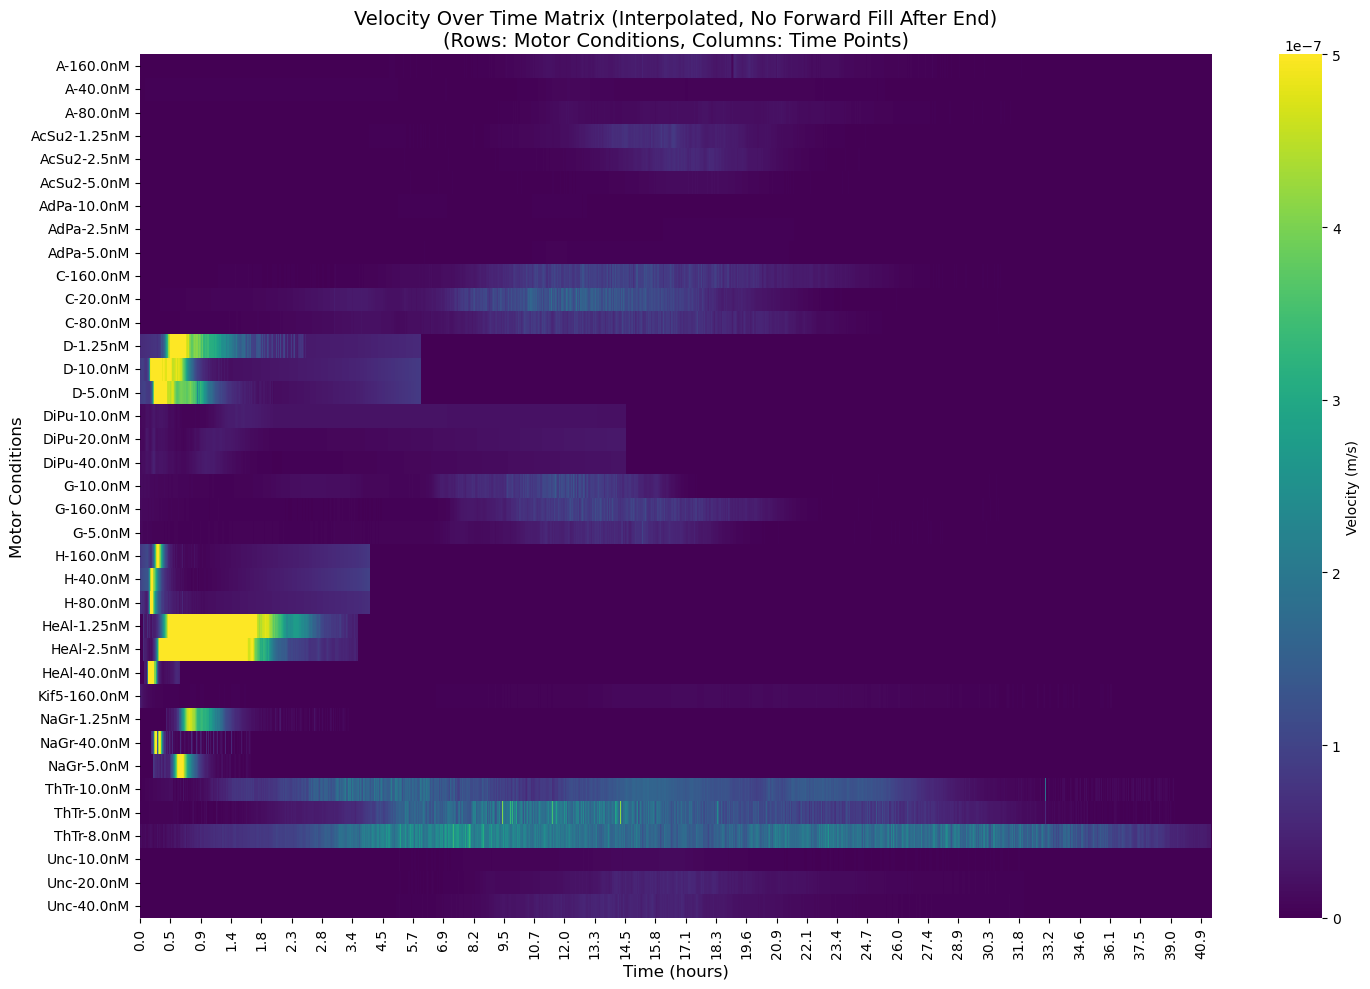

In [7]:
# To avoid artificially extending the last value for motors that finish early,
# we will only interpolate between the first and last valid time points for each motor.
# After the last valid value, we will keep as NaN (not fill forward).

# Interpolate missing values in the velocity matrix (linear, only between valid points)
velocity_matrix_interp = velocity_matrix.copy()
for col in velocity_matrix_interp.columns:
    # Only interpolate between first and last valid index
    s = velocity_matrix_interp[col]
    first_valid = s.first_valid_index()
    last_valid = s.last_valid_index()
    # Interpolate only within the valid range
    s_interp = s.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
    # Reconstruct the full column: keep NaN before/after, interpolated in the middle
    s_new = pd.Series(np.nan, index=s.index)
    s_new.loc[first_valid:last_valid] = s_interp
    velocity_matrix_interp[col] = s_new

# For visualization, fill remaining NaNs with 0 (but do NOT use this for analysis)
velocity_matrix_interp_clean = velocity_matrix_interp.fillna(0)

plt.figure(figsize=(15, 10))

vmax = 0.5e-6

# Plot the heatmap as before
ax = sns.heatmap(
    velocity_matrix_interp_clean.T, 
    cmap='viridis', 
    cbar_kws={'label': 'Velocity (m/s)'},
    xticklabels=500,  # Show every 500th time point (fewer ticks)
    yticklabels=True,
    vmax=vmax
)

# Transform x-tick labels from seconds to hours
xticks = ax.get_xticks()
xtick_labels = velocity_matrix_interp_clean.index.values[xticks.astype(int)]
xtick_labels_hours = xtick_labels / 3600
ax.set_xticklabels([f"{x:.1f}" for x in xtick_labels_hours])

plt.title('Velocity Over Time Matrix (Interpolated, No Forward Fill After End)\n(Rows: Motor Conditions, Columns: Time Points)', fontsize=14)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Motor Conditions', fontsize=12)

plt.tight_layout()
# Save the last matplotlib figure as JPG with 300 dpi BEFORE plt.show()
# plt.savefig("../../../../Downloads/velocity_matrix_interpolated.jpg", format="jpg", dpi=300)

plt.show()


## NMF Analysis: Quantitative Motor Clustering

**Goal**: Use Non-Negative Matrix Factorization to discover quantitative groups of motors and identify which data features best separate them.


In [8]:
df

,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,work [J]_mean,protein,DNA nM,translation rate [nM/s]
1834,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-160.0nM,160.0,0.000000
3662,60.0,NaN,1.872926e-07,2.564178e-07,7.056967e-10,-2.368822e-08,1.584352e-07,NaN,4.686639e-17,A-160.0nM,160.0,0.000000
3663,120.0,NaN,1.869066e-07,2.576449e-07,7.106040e-10,-2.493466e-08,1.590402e-07,NaN,4.671996e-17,A-160.0nM,160.0,0.000000
3664,180.0,NaN,1.863465e-07,2.594255e-07,7.155113e-10,-2.618110e-08,1.596452e-07,NaN,4.657353e-17,A-160.0nM,160.0,0.000000
3665,240.0,NaN,1.856325e-07,2.616953e-07,7.204186e-10,-2.742754e-08,1.602502e-07,NaN,4.642711e-17,A-160.0nM,160.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
240982,125550.0,1995.219899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,0.014096
240986,125640.0,1992.982738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,-0.024857
240990,125730.0,1992.247635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,-0.008168
240994,125820.0,1993.150021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unc-40.0nM,40.0,0.010027


In [9]:
# Step 1: Create Comprehensive Features Matrix
# Matt: "make a big matrix-- that those 'data features' over time for all motors"

# Create matrices for each PIV feature
features = ['velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 
           'strain [1/s]_mean', 'shear [1/s]_mean', 'work [J]_mean', 'translation rate [nM/s]']

feature_matrices = {}
for feature in features:
    matrix = df.pivot_table(
        index='time (s)', 
        columns='protein', 
        values=feature,
        aggfunc='mean'
    )
    feature_matrices[feature] = matrix
    print(f"{feature}: {matrix.shape}")

# Combine all features into one big matrix
# Shape: (time_points, motor_conditions * n_features)
all_features_list = []
feature_names = []

for feature, matrix in feature_matrices.items():
    # Interpolate missing values for each feature matrix
    matrix_interp = matrix.copy()
    for col in matrix_interp.columns:
        s = matrix_interp[col]
        first_valid = s.first_valid_index()
        last_valid = s.last_valid_index()
        if first_valid is not None and last_valid is not None:
            s_interp = s.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
            s_new = pd.Series(np.nan, index=s.index)
            s_new.loc[first_valid:last_valid] = s_interp
            matrix_interp[col] = s_new
    
    # Fill remaining NaNs with 0 for NMF (NMF requires non-negative values)
    matrix_clean = matrix_interp.fillna(0)
    
    # Add to combined matrix
    all_features_list.append(matrix_clean)
    feature_names.extend([f"{feature}_{col}" for col in matrix_clean.columns])

# Combine all features horizontally
combined_features_matrix = pd.concat(all_features_list, axis=1)
combined_features_matrix.columns = feature_names

print(f"\nCombined features matrix shape: {combined_features_matrix.shape}")
print(f"Features: {len(features)}")
print(f"Motor conditions: {len(df['protein'].unique())}")
print(f"Time points: {combined_features_matrix.shape[0]}")
print(f"Total features: {combined_features_matrix.shape[1]}")

# Show the structure
print(f"\nFeature breakdown:")
for i, feature in enumerate(features):
    start_idx = i * len(df['protein'].unique())
    end_idx = (i + 1) * len(df['protein'].unique())
    print(f"  {feature}: columns {start_idx}-{end_idx-1}")


velocity magnitude [m/s]_mean: (17685, 37)
vorticity [1/s]_mean: (17685, 37)
divergence [1/s]_mean: (17685, 37)
strain [1/s]_mean: (17685, 37)
shear [1/s]_mean: (17685, 37)
work [J]_mean: (17685, 37)
translation rate [nM/s]: (20093, 37)

Combined features matrix shape: (20093, 259)
Features: 7
Motor conditions: 37
Time points: 20093
Total features: 259

Feature breakdown:
  velocity magnitude [m/s]_mean: columns 0-36
  vorticity [1/s]_mean: columns 37-73
  divergence [1/s]_mean: columns 74-110
  strain [1/s]_mean: columns 111-147
  shear [1/s]_mean: columns 148-184
  work [J]_mean: columns 185-221
  translation rate [nM/s]: columns 222-258


In [10]:
# Step 2: NMF Analysis
# Import NMF from sklearn
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# Prepare data for NMF
# NMF works on the transpose: (motor_conditions, time_features)
# Each row = one motor condition, each column = one time point for one feature

# Reshape the data: (motor_conditions, time_points * n_features)
motor_conditions = df['protein'].unique()
n_motors = len(motor_conditions)
n_timepoints = combined_features_matrix.shape[0]
n_features = len(features)

# Create the NMF input matrix
# Shape: (motor_conditions, time_points * n_features)
nmf_input_matrix = np.zeros((n_motors, n_timepoints * n_features))

for i, motor in enumerate(motor_conditions):
    for j, feature in enumerate(features):
        start_col = j * n_timepoints
        end_col = (j + 1) * n_timepoints
        
        # Get the time series for this motor and feature
        motor_feature_data = combined_features_matrix[f"{feature}_{motor}"]
        nmf_input_matrix[i, start_col:end_col] = motor_feature_data.values

print(f"NMF input matrix shape: {nmf_input_matrix.shape}")
print(f"Motor conditions: {n_motors}")
print(f"Time points per feature: {n_timepoints}")
print(f"Features: {n_features}")
print(f"Total dimensions: {n_timepoints * n_features}")

# Check for NaN and negative values (NMF requires non-negative and finite values)
print(f"Matrix contains NaN values: {np.isnan(nmf_input_matrix).any()}")
print(f"Number of NaN values: {np.isnan(nmf_input_matrix).sum()}")
print(f"Percentage of NaN values: {np.isnan(nmf_input_matrix).sum() / nmf_input_matrix.size * 100:.2f}%")

# Handle NaN values by filling with 0 (since NMF requires non-negative values)
if np.isnan(nmf_input_matrix).any():
    print("Filling NaN values with 0 for NMF analysis...")
    nmf_input_matrix = np.nan_to_num(nmf_input_matrix, nan=0.0)

# Check for negative values (NMF requires non-negative)
min_val = np.min(nmf_input_matrix)
print(f"Minimum value in matrix: {min_val}")

if min_val < 0:
    print("Warning: Negative values found. Shifting to make non-negative...")
    nmf_input_matrix = nmf_input_matrix - min_val + 1e-10
    print(f"After shift - minimum value: {np.min(nmf_input_matrix)}")

# Final validation
print(f"\nFinal matrix properties:")
print(f"Shape: {nmf_input_matrix.shape}")
print(f"Contains NaN: {np.isnan(nmf_input_matrix).any()}")
print(f"Contains negative values: {(nmf_input_matrix < 0).any()}")
print(f"Minimum value: {np.min(nmf_input_matrix)}")
print(f"Maximum value: {np.max(nmf_input_matrix)}")
print(f"Non-zero elements: {np.count_nonzero(nmf_input_matrix)}")
print(f"Sparsity: {1 - np.count_nonzero(nmf_input_matrix) / nmf_input_matrix.size:.4f}")




NMF input matrix shape: (37, 140651)
Motor conditions: 37
Time points per feature: 20093
Features: 7
Total dimensions: 140651
Matrix contains NaN values: True
Number of NaN values: 534576
Percentage of NaN values: 10.27%
Filling NaN values with 0 for NMF analysis...
Minimum value in matrix: -0.64661282838505
After shift - minimum value: 1e-10

Final matrix properties:
Shape: (37, 140651)
Contains NaN: False
Contains negative values: False
Minimum value: 1e-10
Maximum value: 1.4968198045534091
Non-zero elements: 5204087
Sparsity: 0.0000



Running NMF with 2 components...
  Reconstruction error: 0.000017

Running NMF with 3 components...
  Reconstruction error: 0.000016

Running NMF with 4 components...
  Reconstruction error: 0.000015

Running NMF with 5 components...
  Reconstruction error: 0.000013

Running NMF with 6 components...
  Reconstruction error: 0.000008

Running NMF with 8 components...
  Reconstruction error: 0.000008

Running NMF with 10 components...
  Reconstruction error: 0.000002


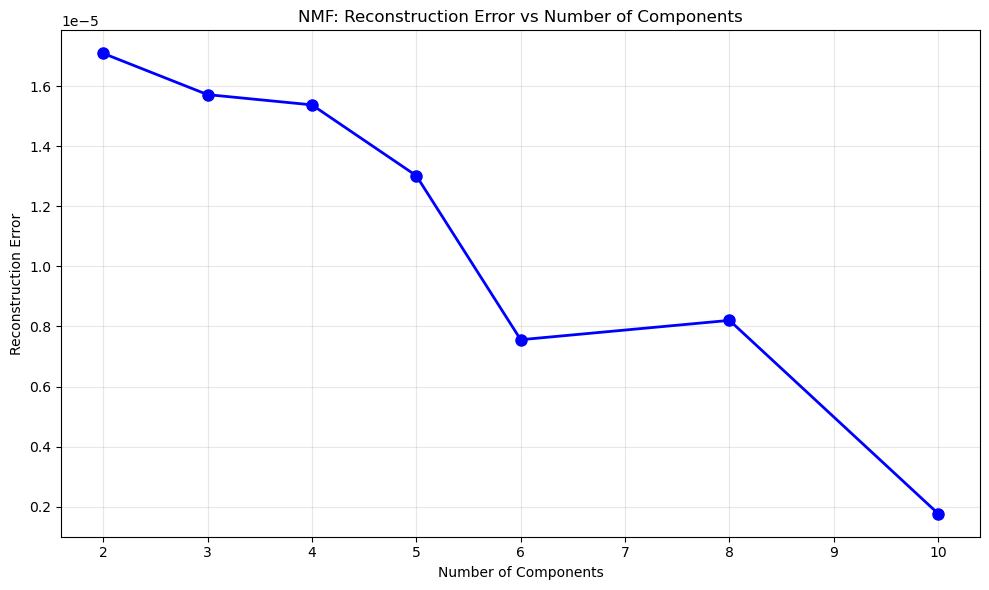


Best number of components: 10


In [11]:
# Step 3: Run NMF with different numbers of components
# Test different numbers of components to find the best decomposition

# Try different numbers of components
n_components_list = [2, 3, 4, 5, 6, 8, 10]
nmf_results = {}

for n_components in n_components_list:
    print(f"\nRunning NMF with {n_components} components...")
    
    # Initialize NMF
    nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
    
    # Fit NMF
    W = nmf.fit_transform(nmf_input_matrix)  # Motor weights (n_motors, n_components)
    H = nmf.components_  # Feature patterns (n_components, n_timepoints * n_features)
    
    # Calculate reconstruction error
    reconstruction = W @ H
    reconstruction_error = np.mean((nmf_input_matrix - reconstruction) ** 2)
    
    nmf_results[n_components] = {
        'W': W,  # Motor weights
        'H': H,  # Feature patterns
        'reconstruction_error': reconstruction_error,
        'nmf': nmf
    }
    
    print(f"  Reconstruction error: {reconstruction_error:.6f}")

# Plot reconstruction error vs number of components
plt.figure(figsize=(10, 6))
errors = [nmf_results[n]['reconstruction_error'] for n in n_components_list]
plt.plot(n_components_list, errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error')
plt.title('NMF: Reconstruction Error vs Number of Components')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Choose the best number of components (lowest error)
best_n_components = n_components_list[np.argmin(errors)]
print(f"\nBest number of components: {best_n_components}")

# Get the best NMF results
best_nmf = nmf_results[best_n_components]
W_best = best_nmf['W']  # Motor weights
H_best = best_nmf['H']  # Feature patterns


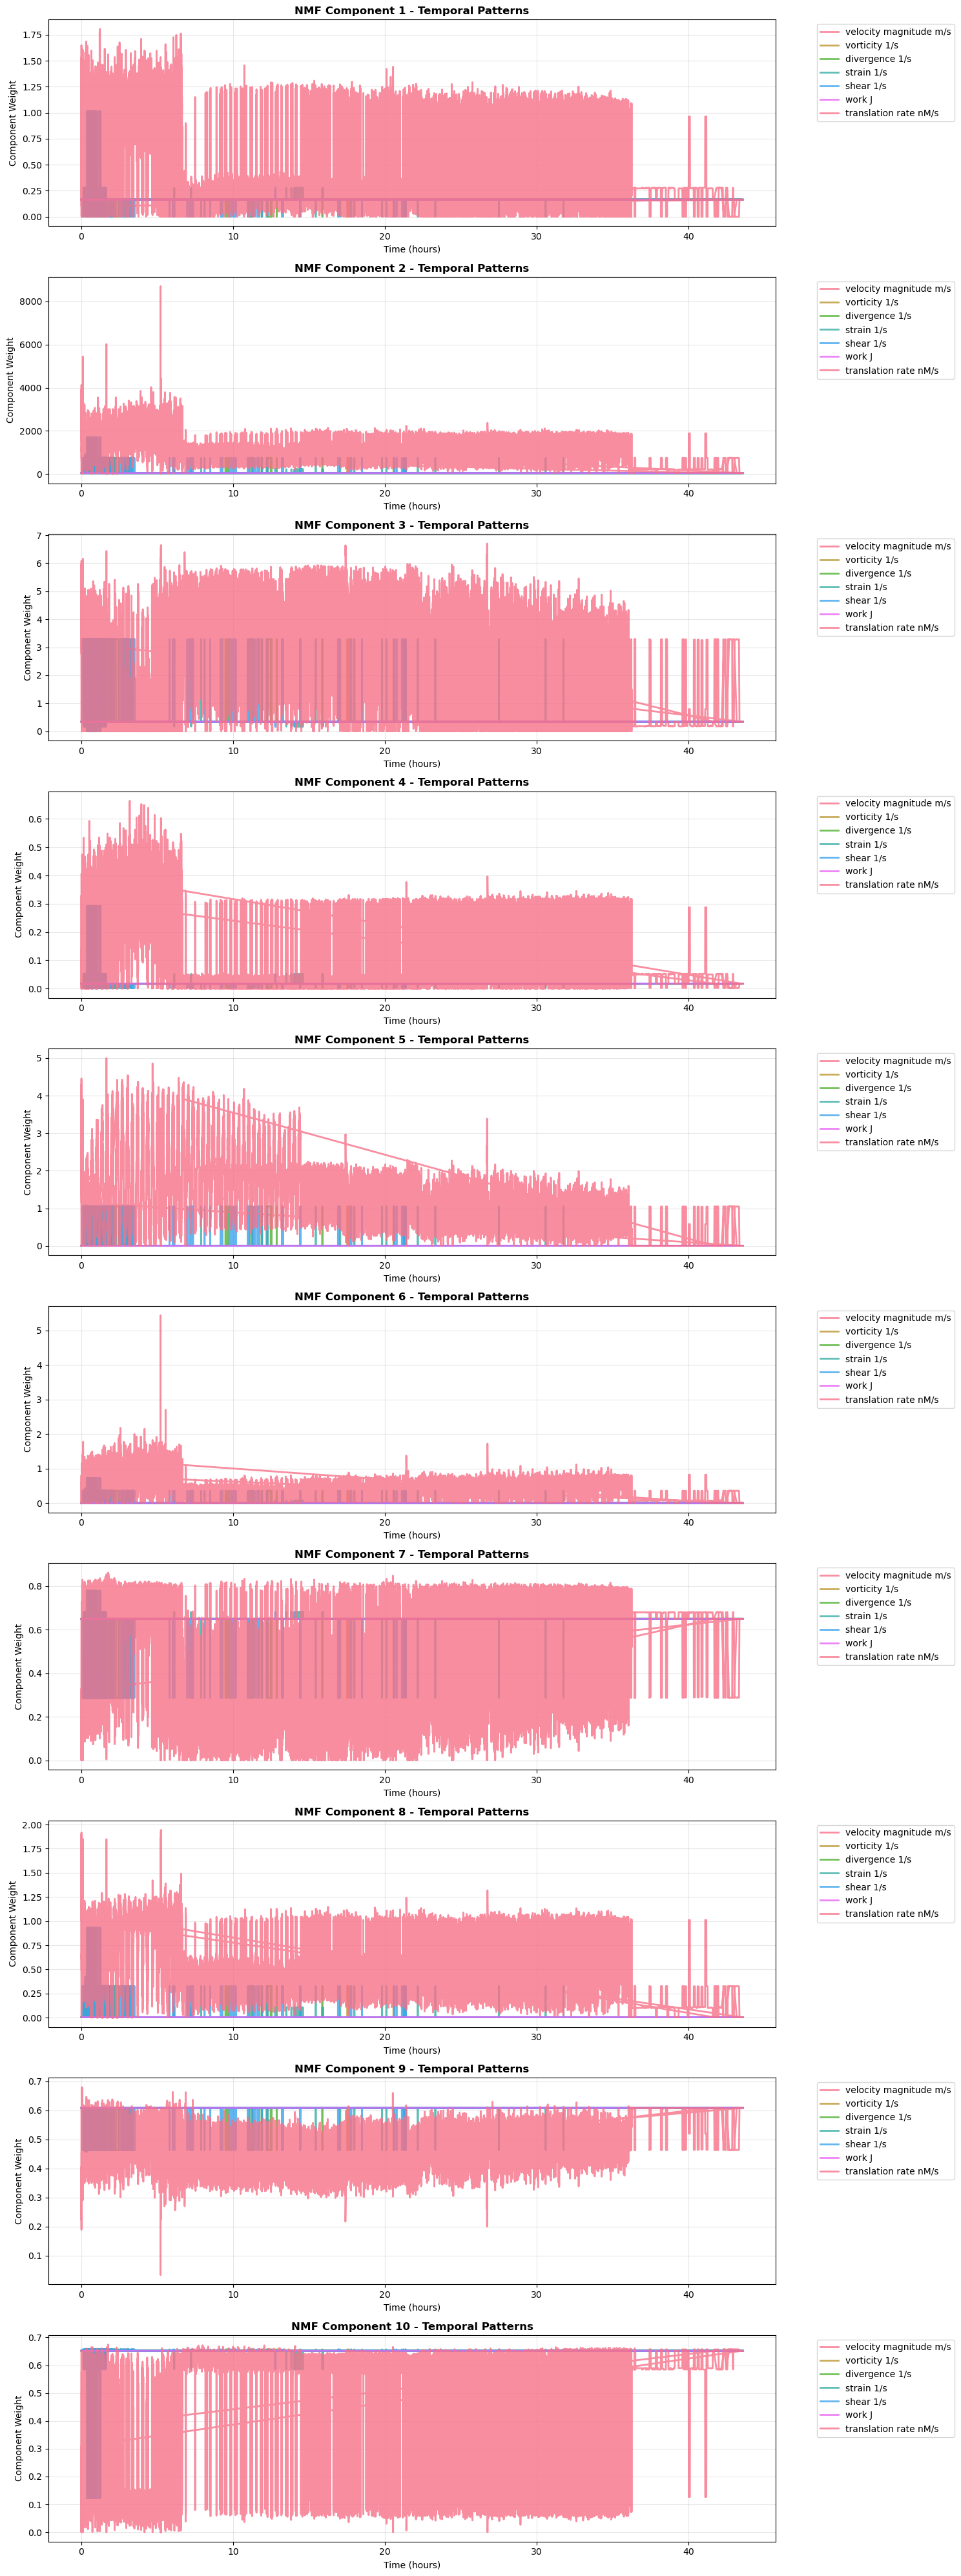


NMF Component Analysis:
Number of components: 10
Each component represents a temporal pattern across all 7 features
Component shapes: (10, 140651)
Motor weight shapes: (37, 10)


In [12]:
# Step 4: Visualize NMF Components (Feature Patterns)
# Each component represents a temporal pattern across all features

fig, axes = plt.subplots(best_n_components, 1, figsize=(15, 4 * best_n_components))
if best_n_components == 1:
    axes = [axes]

for comp_idx in range(best_n_components):
    ax = axes[comp_idx]
    
    # Get the component pattern
    component_pattern = H_best[comp_idx, :]  # Shape: (n_timepoints * n_features,)
    
    # Reshape to separate features
    component_reshaped = component_pattern.reshape(n_features, n_timepoints)
    
    # Plot each feature's temporal pattern
    for feat_idx, feature in enumerate(features):
        time_axis = combined_features_matrix.index.values / 3600  # Convert to hours
        ax.plot(time_axis, component_reshaped[feat_idx, :], 
               label=feature.replace('_mean', '').replace('[', '').replace(']', ''), 
               linewidth=2, alpha=0.8)
    
    ax.set_title(f'NMF Component {comp_idx + 1} - Temporal Patterns', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Component Weight')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print component interpretation
print(f"\nNMF Component Analysis:")
print(f"Number of components: {best_n_components}")
print(f"Each component represents a temporal pattern across all {len(features)} features")
print(f"Component shapes: {H_best.shape}")
print(f"Motor weight shapes: {W_best.shape}")


n_clusters=2: silhouette_score=0.674
n_clusters=3: silhouette_score=0.742
n_clusters=4: silhouette_score=0.757
n_clusters=5: silhouette_score=0.770
n_clusters=6: silhouette_score=0.760

Best number of clusters: 5

Motor Clustering Results:
Cluster 0: ['HeAl-2.5nM', 'NaGr-40.0nM', 'Unc-10.0nM', 'Unc-20.0nM']
Cluster 1: ['A-160.0nM', 'A-40.0nM', 'A-80.0nM', 'AcSu2-1.25nM', 'AcSu2-2.5nM', 'AcSu2-5.0nM', 'C-160.0nM', 'C-20.0nM', 'C-80.0nM', 'D-1.25nM', 'D-10.0nM', 'D-5.0nM', 'DiPu-10.0nM', 'DiPu-20.0nM', 'DiPu-40.0nM', 'G-10.0nM', 'G-160.0nM', 'G-5.0nM', 'H-160.0nM', 'H-40.0nM', 'H-80.0nM', 'NaGr-1.25nM', 'ThTr-10.0nM', 'ThTr-5.0nM', 'ThTr-8.0nM']
Cluster 2: ['AdPa-10.0nM', 'AdPa-5.0nM', 'HeAl-1.25nM', 'Kif5-160.0nM', 'NaGr-5.0nM']
Cluster 3: ['HeAl-40.0nM', 'Unc-40.0nM']
Cluster 4: ['AdPa-2.5nM']


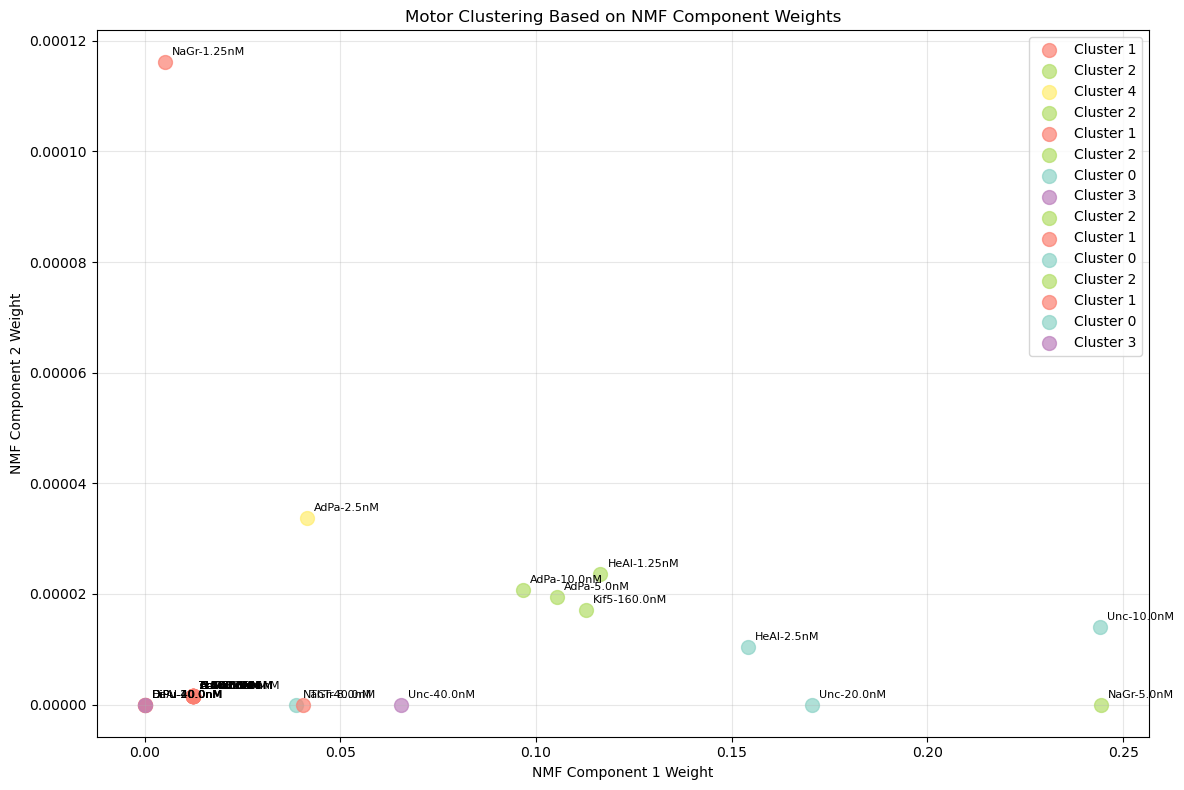

In [13]:
# Step 5: Motor Clustering Based on NMF Weights
# Use the motor weights (W matrix) to cluster motors

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster motors based on their NMF component weights
n_clusters_list = [2, 3, 4, 5, 6]
silhouette_scores = []

for n_clusters in n_clusters_list:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(W_best)
    silhouette_avg = silhouette_score(W_best, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"n_clusters={n_clusters}: silhouette_score={silhouette_avg:.3f}")

# Choose best number of clusters
best_n_clusters = n_clusters_list[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters: {best_n_clusters}")

# Final clustering
kmeans_final = KMeans(n_clusters=best_n_clusters, random_state=42)
motor_clusters = kmeans_final.fit_predict(W_best)

# Create motor clustering dataframe
motor_cluster_df = pd.DataFrame({
    'motor': motor_conditions,
    'cluster': motor_clusters,
    'component_weights': [W_best[i, :] for i in range(len(motor_conditions))]
})

print(f"\nMotor Clustering Results:")
for cluster_id in range(best_n_clusters):
    cluster_motors = motor_cluster_df[motor_cluster_df['cluster'] == cluster_id]['motor'].tolist()
    print(f"Cluster {cluster_id}: {cluster_motors}")

# Visualize motor weights
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, best_n_clusters))

for i, motor in enumerate(motor_conditions):
    cluster_id = motor_clusters[i]
    plt.scatter(W_best[i, 0], W_best[i, 1], 
               c=[colors[cluster_id]], s=100, alpha=0.7, 
               label=f'Cluster {cluster_id}' if i == 0 or motor_clusters[i-1] != cluster_id else "")
    plt.annotate(motor, (W_best[i, 0], W_best[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel(f'NMF Component 1 Weight')
plt.ylabel(f'NMF Component 2 Weight')
plt.title('Motor Clustering Based on NMF Component Weights')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


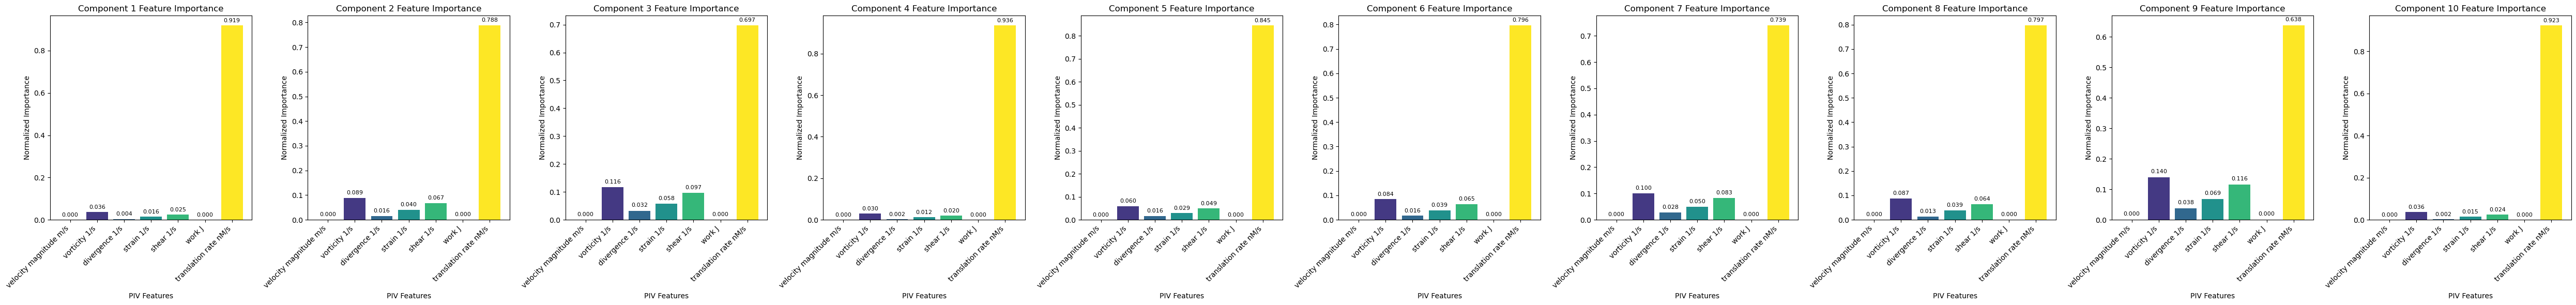


Feature Importance Analysis:
Most important features for motor grouping:

Component 1:
  1. translation rate nM/s: 0.919
  2. vorticity 1/s: 0.036
  3. shear 1/s: 0.025
  4. strain 1/s: 0.016
  5. divergence 1/s: 0.004
  6. velocity magnitude m/s: 0.000
  7. work J: 0.000

Component 2:
  1. translation rate nM/s: 0.788
  2. vorticity 1/s: 0.089
  3. shear 1/s: 0.067
  4. strain 1/s: 0.040
  5. divergence 1/s: 0.016
  6. velocity magnitude m/s: 0.000
  7. work J: 0.000

Component 3:
  1. translation rate nM/s: 0.697
  2. vorticity 1/s: 0.116
  3. shear 1/s: 0.097
  4. strain 1/s: 0.058
  5. divergence 1/s: 0.032
  6. velocity magnitude m/s: 0.000
  7. work J: 0.000

Component 4:
  1. translation rate nM/s: 0.936
  2. vorticity 1/s: 0.030
  3. shear 1/s: 0.020
  4. strain 1/s: 0.012
  5. divergence 1/s: 0.002
  6. velocity magnitude m/s: 0.000
  7. work J: 0.000

Component 5:
  1. translation rate nM/s: 0.845
  2. vorticity 1/s: 0.060
  3. shear 1/s: 0.049
  4. strain 1/s: 0.029
  5. di

In [14]:
# Step 6: Feature Importance Analysis
# Identify which PIV features most influence the motor grouping

# Calculate feature importance for each component
feature_importance = np.zeros((best_n_components, len(features)))

for comp_idx in range(best_n_components):
    component_pattern = H_best[comp_idx, :]
    component_reshaped = component_pattern.reshape(n_features, n_timepoints)
    
    # Calculate the variance/activity of each feature in this component
    for feat_idx in range(len(features)):
        feature_activity = np.var(component_reshaped[feat_idx, :])
        feature_importance[comp_idx, feat_idx] = feature_activity

# Normalize importance scores
feature_importance_norm = feature_importance / np.sum(feature_importance, axis=1, keepdims=True)

# Plot feature importance
fig, axes = plt.subplots(1, best_n_components, figsize=(5 * best_n_components, 6))
if best_n_components == 1:
    axes = [axes]

for comp_idx in range(best_n_components):
    ax = axes[comp_idx]
    
    # Get importance scores for this component
    importance_scores = feature_importance_norm[comp_idx, :]
    feature_names_clean = [f.replace('_mean', '').replace('[', '').replace(']', '') for f in features]
    
    # Create bar plot
    bars = ax.bar(range(len(features)), importance_scores, 
                 color=plt.cm.viridis(np.linspace(0, 1, len(features))))
    ax.set_title(f'Component {comp_idx + 1} Feature Importance')
    ax.set_xlabel('PIV Features')
    ax.set_ylabel('Normalized Importance')
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(feature_names_clean, rotation=45, ha='right')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{importance_scores[i]:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print feature importance summary
print(f"\nFeature Importance Analysis:")
print(f"Most important features for motor grouping:")
for comp_idx in range(best_n_components):
    print(f"\nComponent {comp_idx + 1}:")
    comp_importance = feature_importance_norm[comp_idx, :]
    sorted_indices = np.argsort(comp_importance)[::-1]  # Sort descending
    
    for i, idx in enumerate(sorted_indices):
        feature_name = features[idx].replace('_mean', '').replace('[', '').replace(']', '')
        print(f"  {i+1}. {feature_name}: {comp_importance[idx]:.3f}")


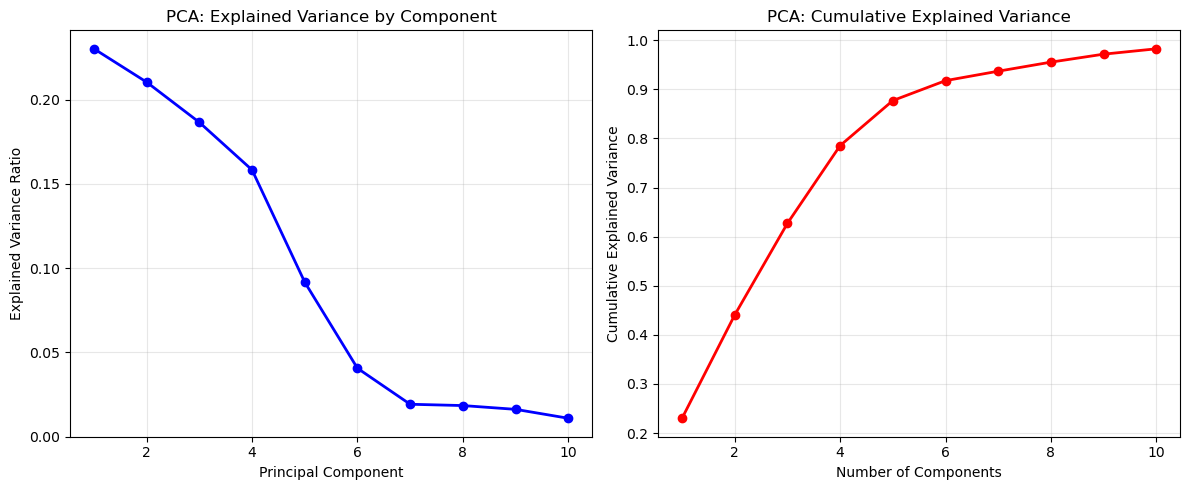

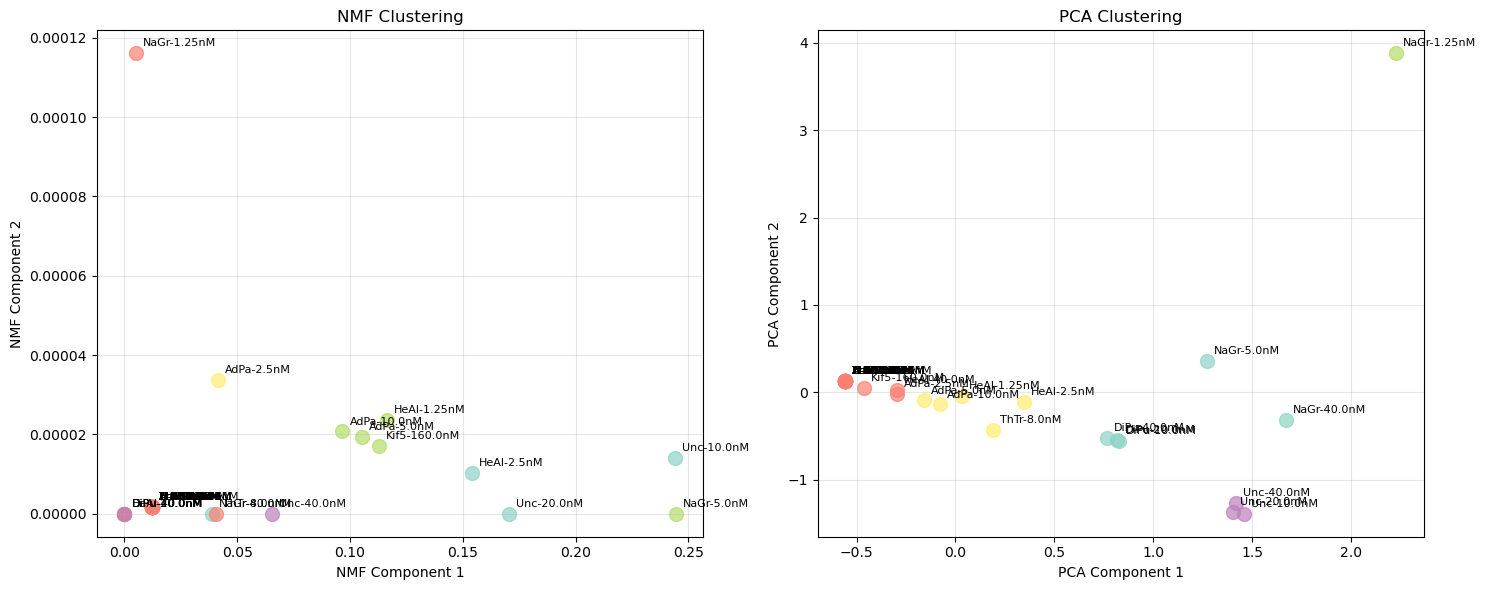


Clustering Comparison:
NMF vs PCA clustering agreement:
Agreement: 0.595 (59.5%)

Motors with different clustering:
  AdPa-10.0nM: NMF cluster 2, PCA cluster 4
  AdPa-2.5nM: NMF cluster 4, PCA cluster 1
  AdPa-5.0nM: NMF cluster 2, PCA cluster 4
  DiPu-10.0nM: NMF cluster 1, PCA cluster 0
  DiPu-20.0nM: NMF cluster 1, PCA cluster 0
  DiPu-40.0nM: NMF cluster 1, PCA cluster 0
  HeAl-1.25nM: NMF cluster 2, PCA cluster 4
  HeAl-2.5nM: NMF cluster 0, PCA cluster 4
  HeAl-40.0nM: NMF cluster 3, PCA cluster 1
  Kif5-160.0nM: NMF cluster 2, PCA cluster 1
  NaGr-1.25nM: NMF cluster 1, PCA cluster 2
  NaGr-5.0nM: NMF cluster 2, PCA cluster 0
  ThTr-8.0nM: NMF cluster 1, PCA cluster 4
  Unc-10.0nM: NMF cluster 0, PCA cluster 3
  Unc-20.0nM: NMF cluster 0, PCA cluster 3


In [15]:
# Step 7: Compare NMF vs PCA Results
# Run PCA on the same data for comparison

from sklearn.decomposition import PCA

# Run PCA on the same data
pca = PCA()
pca_result = pca.fit_transform(nmf_input_matrix)

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, min(11, pca_result.shape[1] + 1)), 
         pca.explained_variance_ratio_[:10], 'bo-', linewidth=2, markersize=6)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Explained Variance by Component')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, min(11, pca_result.shape[1] + 1)), 
         np.cumsum(pca.explained_variance_ratio_[:10]), 'ro-', linewidth=2, markersize=6)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare NMF and PCA clustering
# Use first 2 components for both methods
pca_2d = pca_result[:, :2]

# Cluster PCA results
kmeans_pca = KMeans(n_clusters=best_n_clusters, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_2d)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# NMF clustering
colors = plt.cm.Set3(np.linspace(0, 1, best_n_clusters))
for i, motor in enumerate(motor_conditions):
    cluster_id = motor_clusters[i]
    ax1.scatter(W_best[i, 0], W_best[i, 1], 
               c=[colors[cluster_id]], s=100, alpha=0.7)
    ax1.annotate(motor, (W_best[i, 0], W_best[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax1.set_xlabel('NMF Component 1')
ax1.set_ylabel('NMF Component 2')
ax1.set_title('NMF Clustering')
ax1.grid(True, alpha=0.3)

# PCA clustering
for i, motor in enumerate(motor_conditions):
    cluster_id = pca_clusters[i]
    ax2.scatter(pca_2d[i, 0], pca_2d[i, 1], 
               c=[colors[cluster_id]], s=100, alpha=0.7)
    ax2.annotate(motor, (pca_2d[i, 0], pca_2d[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.set_title('PCA Clustering')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare clustering results
print(f"\nClustering Comparison:")
print(f"NMF vs PCA clustering agreement:")

# Calculate agreement between NMF and PCA clustering
agreement = np.mean(motor_clusters == pca_clusters)
print(f"Agreement: {agreement:.3f} ({agreement*100:.1f}%)")

# Show which motors are grouped differently
disagreements = motor_clusters != pca_clusters
if np.any(disagreements):
    print(f"\nMotors with different clustering:")
    for i, motor in enumerate(motor_conditions):
        if disagreements[i]:
            print(f"  {motor}: NMF cluster {motor_clusters[i]}, PCA cluster {pca_clusters[i]}")
else:
    print("All motors have the same clustering in both methods!")


In [16]:
# Step 8: Summary and Interpretation

print("="*60)
print("NMF ANALYSIS SUMMARY")
print("="*60)

print(f"\n1. DATA STRUCTURE:")
print(f"   • Motor conditions: {len(motor_conditions)}")
print(f"   • Time points: {n_timepoints}")
print(f"   • PIV features: {len(features)}")
print(f"   • Total dimensions: {nmf_input_matrix.shape[1]}")

print(f"\n2. NMF DECOMPOSITION:")
print(f"   • Best number of components: {best_n_components}")
print(f"   • Reconstruction error: {best_nmf['reconstruction_error']:.6f}")

print(f"\n3. MOTOR CLUSTERING:")
print(f"   • Best number of clusters: {best_n_clusters}")
print(f"   • Clustering method: K-means on NMF component weights")
for cluster_id in range(best_n_clusters):
    cluster_motors = motor_cluster_df[motor_cluster_df['cluster'] == cluster_id]['motor'].tolist()
    print(f"   • Cluster {cluster_id}: {cluster_motors}")

print(f"\n4. FEATURE IMPORTANCE:")
print(f"   • Most influential PIV features for motor grouping:")
for comp_idx in range(best_n_components):
    comp_importance = feature_importance_norm[comp_idx, :]
    top_feature_idx = np.argmax(comp_importance)
    top_feature = features[top_feature_idx].replace('_mean', '').replace('[', '').replace(']', '')
    print(f"   • Component {comp_idx + 1}: {top_feature} ({comp_importance[top_feature_idx]:.3f})")

print(f"\n5. NMF vs PCA COMPARISON:")
print(f"   • Clustering agreement: {agreement:.3f} ({agreement*100:.1f}%)")

print(f"\n6. KEY INSIGHTS:")
print(f"   • NMF components represent temporal patterns of motor behavior")
print(f"   • Each component shows how different PIV features vary over time")
print(f"   • Motor clustering reveals groups with similar behavioral patterns")
print(f"   • Feature importance identifies which PIV measurements matter most")

print("\n" + "="*60)
print("NMF ANALYSIS COMPLETE")
print("="*60)


NMF ANALYSIS SUMMARY

1. DATA STRUCTURE:
   • Motor conditions: 37
   • Time points: 20093
   • PIV features: 7
   • Total dimensions: 140651

2. NMF DECOMPOSITION:
   • Best number of components: 10
   • Reconstruction error: 0.000002

3. MOTOR CLUSTERING:
   • Best number of clusters: 5
   • Clustering method: K-means on NMF component weights
   • Cluster 0: ['HeAl-2.5nM', 'NaGr-40.0nM', 'Unc-10.0nM', 'Unc-20.0nM']
   • Cluster 1: ['A-160.0nM', 'A-40.0nM', 'A-80.0nM', 'AcSu2-1.25nM', 'AcSu2-2.5nM', 'AcSu2-5.0nM', 'C-160.0nM', 'C-20.0nM', 'C-80.0nM', 'D-1.25nM', 'D-10.0nM', 'D-5.0nM', 'DiPu-10.0nM', 'DiPu-20.0nM', 'DiPu-40.0nM', 'G-10.0nM', 'G-160.0nM', 'G-5.0nM', 'H-160.0nM', 'H-40.0nM', 'H-80.0nM', 'NaGr-1.25nM', 'ThTr-10.0nM', 'ThTr-5.0nM', 'ThTr-8.0nM']
   • Cluster 2: ['AdPa-10.0nM', 'AdPa-5.0nM', 'HeAl-1.25nM', 'Kif5-160.0nM', 'NaGr-5.0nM']
   • Cluster 3: ['HeAl-40.0nM', 'Unc-40.0nM']
   • Cluster 4: ['AdPa-2.5nM']

4. FEATURE IMPORTANCE:
   • Most influential PIV features for 